# Computational Fluid Dynamics: Refresher

## Mass Conservation
A pure control volume (Eulerian) framework tracks fluid passing through a fixed region in space rather than following a moving particle of fluid. By applying the conservation principle directly to a stationary control volume, we account for mass entering, leaving, and accumulating within defined boundaries.

For any fixed control volume ($CV$) bounded by control surface ($CS$), conservation of mass dictates:

$$\text{Rate of Mass Accumulation inside } CV = \text{Net Rate of Mass Inflow across } CS$$

In integral form:

$$\frac{\partial}{\partial t} \iiint_{CV} \rho \, dV + \iint_{CS} \rho (\mathbf{u} \cdot \mathbf{n}) \, dA = 0$$

where $\rho$ is fluid density, $\mathbf{u} = (u, v, w)$ is velocity, and $\mathbf{n}$ is the outward-facing unit normal vector. Recall Gauss' divergence theorm:

$$ \iint_{CS} \rho (\mathbf{u} \cdot \mathbf{n}) \, dA = \iiint_{CV} \nabla \cdot \left( \rho \mathbf{u} \right)  dV $$

We can apply this to the conveciton term, allowing us to transform the surface integral into a volume integral. If the control volume becomes infinitesimally small, we can write a differential form of the continuity equation:

$$ \frac{\partial \rho}{\partial t} + \nabla \cdot \left( \rho \mathbf{u} \right) = 0 $$

We will adopt the Einstein convention that whenever the same index appears twice in any term, summation over the range of that index is implied:

$$\frac{\partial \rho}{\partial t} + \frac{\left( \partial \rho u_i \right)}{\partial x_i} = \frac{\partial \rho}{\partial t} + \frac{\left( \partial \rho u_x \right)}{\partial x} + \frac{\left( \partial \rho u_y \right)}{\partial y} + \frac{\left( \partial \rho u_z \right)}{\partial z} $$

where $x_i$ ($i=1,2,3$) or ($x,y,z$) are the Cartesian coordinates and $u_i$ or $(u_x,u_y,u_z)$ are the Cartesian components of the velocity vector $\mathbf{u}$.

## Momentum Conservation

Newton's second law applied to a fixed control volume states that the rate of change of linear momentum inside the control volume, plus the net rate of momentum leaving through the control surface, equals the sum of external forces acting on the fluid within the volume:

$$\text{Accumulation of Momentum} + \text{Net Outflow of Momentum} = \sum \mathbf{F}_{\text{external}}$$

Written in vector form for a fixed control volume ($CV$) bounded by control surface ($CS$):

$$\frac{\partial}{\partial t} \iiint_{CV} \rho \mathbf{u} \, dV + \iint_{CS} \rho \mathbf{u} (\mathbf{u} \cdot \mathbf{n}) \, dA = \sum \mathbf{f}$$

To determine the right hand side in terms of intensive properties, one neds to consider the forces that can act on the fluid in a CV, which include surface forces (pressure, normal and shear stresses, surface tension, etc.) and body forces (gravity, centrifugal, and coriolis forces, electromagnetic forces, etc.). The surface forces due to pressure and stresses are the microscopic momentum fluxes across a surface. If the fluxes cannot be written as a function of the properties whose conservation the equations govern (density and velocity), the system of equations is not closed. This can be avoided by assuming that the fluid is Newtonian, which applies to many actual fluids.

For Newtonian fluids, the stress tensor $\mathbf{T}$, which is the molecular rate of transport of momentum, can be written as:

$$\mathbf{T} = - \left(p + \frac{2}{3} \mu \nabla \cdot \mathbf{u} \right) \mathbf{I} + 2 \mu \mathbf{D} $$

where $\mu$ is the dynamic viscosity, $\mathbf{I}$ is the unit tensor, $p$ is the static pressure, and $\mathbf{D}$ is the rate of strain tensor:

$$ \mathbf{D} = \frac{1}{2} \left[ \nabla \mathbf{u} + \left(\nabla \mathbf{u} \right)^T \right] $$

These equations may be written using index notation in Cartesian coordinates as:

$$T_{ij} = -\left( p + \frac{2}{3} \mu \frac{\partial u_j}{\partial x_j} \right) \delta_{ij} + 2 \mu D_{ij}$$

$$D_{ij} = \frac{1}{2} \left( \frac{\partial u_i}{\partial x_j} + \frac{\partial u_j}{\partial x_i} \right)$$

where $\delta_{ij}$ is the Kronecker delta ($\delta_{ij} = 1$ if $i = j$, and $0$ if $i \neq j$). Combining these two equations yields:

$$T_{ij} = -\left( p + \frac{2}{3} \mu \frac{\partial u_j}{\partial x_j} \right) \delta_{ij} + \mu \left( \frac{\partial u_i}{\partial x_j} + \frac{\partial u_j}{\partial x_i} \right)$$

For incompressible flows, $\frac{\partial u_j}{\partial x_j}=0$. The following notation is often used to describe the viscous part of the stress tensor:

$$\tau_{ij} = 2 \mu D_{ij} - \frac{2}{3} \mu \delta_{ij} \nabla \cdot \mathbf{u} $$

If we define the body forces (per unit mass) by $\mathbf{b}$, the integral form of the momentum conservation equation is:

$$\frac{\partial}{\partial t} \iiint_{CV} \rho \mathbf{u} \, dV + \iint_{CS} \rho \mathbf{u} (\mathbf{u} \cdot \mathbf{n}) \, dA = \iint_{CS} \mathbf{T} \cdot \mathbf{n} dA + \iiint_{CV} \rho \mathbf{b} dV$$

If we apply Gauss' divergence theorem to the convective and diffusive flux terms, we can write:
$$\frac{\partial \left( \rho \mathbf{u} \right)}{\partial t}  + \nabla \cdot \left( \rho \mathbf{u} \mathbf{u} \right) = \nabla \cdot \mathbf{T}  + \rho \mathbf{b}$$

We can write this for the $i$th Cartesian component as:

$$ \frac{\partial \left( \rho u_i \right)}{\partial t}  + \nabla \cdot \left( \rho u_i \mathbf{u} \right) = \nabla \cdot \mathbf{t}_i  + \rho b_i$$ 

## Lid-driven Cavity

To adapt the general momentum conservation equation to the standard 2D incompressible lid-driven cavity benchmark, we evaluate the terms $\mathbf{D}$, $\mathbf{T}$, and $\mathbf{b}$ under the specific physical assumptions of the problem.

We assume a 2D domain $(x, y)$ with velocity components $\mathbf{u} = (u, v)^T = (u_x, u_y)^T$. We also assume that the flow is incompressible, i.e., that density $\rho$ is constant, simplifying continuity to $\nabla \cdot \mathbf{u} = \frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0$. Finally, we neglect gravity and external field forces, so $\mathbf{b} = \mathbf{0}$.

In 2D Cartesian coordinates, the rate of strain tensor $\mathbf{D} = \frac{1}{2} \left[ \nabla \mathbf{u} + (\nabla \mathbf{u})^T \right]$ is represented as a $2 \times 2$ symmetric matrix:

$$\mathbf{D} = \begin{bmatrix} D_{xx} & D_{xy} \\ D_{yx} & D_{yy} \end{bmatrix} = \begin{bmatrix} \frac{\partial u}{\partial x} & \frac{1}{2} \left( \frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} \right) \\ \frac{1}{2} \left( \frac{\partial v}{\partial x} + \frac{\partial u}{\partial y} \right) & \frac{\partial v}{\partial y} \end{bmatrix}$$

For an incompressible fluid ($\nabla \cdot \mathbf{u} = 0$), the volumetric viscous term $\frac{2}{3}\mu (\nabla \cdot \mathbf{u}) \mathbf{I}$ evaluates to zero. The total stress tensor simplifies to:

$$\mathbf{T} = -p \mathbf{I} + 2 \mu \mathbf{D}$$

Written in matrix form:

$$\mathbf{T} = \begin{bmatrix} T_{xx} & T_{xy} \\ T_{yx} & T_{yy} \end{bmatrix} = \begin{bmatrix} -p + 2\mu \frac{\partial u}{\partial x} & \mu \left( \frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} \right) \\ \mu \left( \frac{\partial v}{\partial x} + \frac{\partial u}{\partial y} \right) & -p + 2\mu \frac{\partial v}{\partial y} \end{bmatrix}$$

The row vector $\mathbf{t}_i$ represents the total stress components acting on the face perpendicular to axis $i$:

$$\mathbf{t}_x = \begin{pmatrix} T_{xx} \\ T_{xy} \end{pmatrix}, \quad \mathbf{t}_y = \begin{pmatrix} T_{yx} \\ T_{yy} \end{pmatrix}$$

Since body forces are set to zero in this problem:

$$\mathbf{b} = \begin{pmatrix} b_x \\ b_y \end{pmatrix} = \begin{pmatrix} 0 \\ 0 \end{pmatrix} \quad \implies \quad b_i = 0$$

Expanding $\frac{\partial \left( \rho u_i \right)}{\partial t} + \nabla \cdot \left( \rho u_i \mathbf{u} \right) = \nabla \cdot \mathbf{t}_i + \rho b_i$ into individual Cartesian components ($x$ and $y$):

The $x$-momentum ($i = 1$ or $x$) is then:

$$\frac{\partial (\rho u)}{\partial t} + \frac{\partial (\rho u u)}{\partial x} + \frac{\partial (\rho u v)}{\partial y} = \frac{\partial T_{xx}}{\partial x} + \frac{\partial T_{xy}}{\partial y}$$

$$\frac{\partial (\rho u)}{\partial t} + \frac{\partial (\rho u u)}{\partial x} + \frac{\partial (\rho u v)}{\partial y} = -\frac{\partial p}{\partial x} + \frac{\partial}{\partial x}\left( 2\mu \frac{\partial u}{\partial x} \right) + \frac{\partial}{\partial y}\left[ \mu \left( \frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} \right) \right]$$

and the $y$-momentum ($i = 2$ or $y$) is then:

$$\frac{\partial (\rho v)}{\partial t} + \frac{\partial (\rho v u)}{\partial x} + \frac{\partial (\rho v v)}{\partial y} = \frac{\partial T_{yx}}{\partial x} + \frac{\partial T_{yy}}{\partial y}$$

$$\frac{\partial (\rho v)}{\partial t} + \frac{\partial (\rho v u)}{\partial x} + \frac{\partial (\rho v v)}{\partial y} = -\frac{\partial p}{\partial y} + \frac{\partial}{\partial x}\left[ \mu \left( \frac{\partial v}{\partial x} + \frac{\partial u}{\partial y} \right) \right] + \frac{\partial}{\partial y}\left( 2\mu \frac{\partial v}{\partial y} \right)$$

We can write this in integral form, assuming constant density ($\rho$) and zero body forces ($\mathbf{b} = \mathbf{0}$), using a 2D planar control volume ($CV$) bounded by control surface ($CS$):

$$\rho \frac{\partial}{\partial t} \iint_{CV} \mathbf{u} \, dA + \rho \iint_{CS} \mathbf{u} (\mathbf{u} \cdot \mathbf{n}) \, dS = -\iint_{CS} p \mathbf{n} \, dS + \mu \iint_{CS} \left[ \nabla \mathbf{u} + (\nabla \mathbf{u})^T \right] \cdot \mathbf{n} \, dS$$

The $x$-Momentum Integral Equation ($i = 1$ or $x$) becomes:

$$\rho \frac{\partial}{\partial t} \iint_{CV} u \, dA + \rho \iint_{CS} u (u n_x + v n_y) \, dS = \iint_{CS} \left[ \left( -p + 2\mu \frac{\partial u}{\partial x} \right) n_x + \mu \left( \frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} \right) n_y \right] dS$$

The $y$-Momentum Integral Equation ($i = 2$ or $y$) becomes:

$$\rho \frac{\partial}{\partial t} \iint_{CV} v \, dA + \rho \iint_{CS} v (u n_x + v n_y) \, dS = \iint_{CS} \left[ \mu \left( \frac{\partial v}{\partial x} + \frac{\partial u}{\partial y} \right) n_x + \left( -p + 2\mu \frac{\partial v}{\partial y} \right) n_y \right] dS$$

where $dA$ represents the 2D area element of $CV$, and $dS$ is the boundary differential element along $CS$ and $\mathbf{n} = (n_x, n_y)^T$ is the outward unit normal vector on $CS$. If we assume steady-state, then the time-derivative terms ($\frac{\partial}{\partial t} \iint_{CV} \dots dA$) evaluate to zero.

## Finite Volume Discretization Framework

To discretize the 2D incompressible momentum equations over a computational grid, we partition the domain into rectangular control volumes (CVs) centered at node $P(i,j)$ with dimensions $\Delta x$ and $\Delta y$. The cell boundaries are labeled by faces: East ($e$), West ($w$), North ($n$), and South ($s$).

```
             N (i, j+1)
                 |
            n ---|---
            |    |    |
   W -------|--  P  --|------- E
(i-1, j)    | (i,j)   |     (i+1, j)
            s ---|---
                 |
             S (i, j-1)

```

---

### Face Flux Formulation

For any transport variable $\phi \in \{u, v\}$, the total surface integral over the control surface $CS$ simplifies to the sum of net fluxes across the four faces:

$$\iint_{CS} \left[ \rho \phi (\mathbf{u} \cdot \mathbf{n}) - \mu (\nabla \phi \cdot \mathbf{n}) \right] dS = J_e - J_w + J_n - J_s$$

where $J_f = J_{f, \text{conv}} + J_{f, \text{diff}}$ represents the total flux across face $f$. The face areas in 2D are $A_e = A_w = \Delta y$ and $A_n = A_s = \Delta x$. Mass flow rates $F_f = \rho u_{n,f} A_f$ govern convective transport across cell faces:

$$F_e = \rho u_e \Delta y, \quad F_w = \rho u_w \Delta y, \quad F_n = \rho v_n \Delta x, \quad F_s = \rho v_s \Delta x$$

Diffusive conductances $D_f = \frac{\mu A_f}{\delta x_f}$ characterize viscous transport across faces using central difference approximations:

$$D_e = \frac{\mu \Delta y}{\Delta x}, \quad D_w = \frac{\mu \Delta y}{\Delta x}, \quad D_n = \frac{\mu \Delta x}{\Delta y}, \quad D_s = \frac{\mu \Delta x}{\Delta y}$$

Evaluating the fluxes at cell boundaries using a central differencing scheme (CDS) yields discrete algebraic equations for each control volume $P$:

$$a_P \phi_P = a_E \phi_E + a_W \phi_W + a_N \phi_N + a_S \phi_S + S_{\phi}$$

The neighbor coefficients $a_{NB}$ account for combined convection-diffusion dynamics:

$$a_E = D_e - \frac{F_e}{2}, \quad a_W = D_w + \frac{F_w}{2}, \quad a_N = D_n - \frac{F_n}{2}, \quad a_S = D_s + \frac{F_s}{2}$$

$$a_P = a_E + a_W + a_N + a_S + (F_e - F_w + F_n - F_s)$$

Pressure gradients integrated over cell volume $CV = \Delta x \Delta y$ act as explicit source terms:

* **$x$-momentum source ($S_u$):** $(p_w - p_e) \Delta y$
* **$y$-momentum source ($S_v$):** $(p_s - p_n) \Delta x$

---

### Example 1: Finite Difference Method

The code solves the 2D incompressible Navier-Stokes equations for Newtonian fluids:

**Continuity Equation (Conservation of Mass):**


$$\nabla \cdot \mathbf{u} = 0 \implies \frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0$$

**Momentum Equations (Conservation of Momentum):**


$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} + v \frac{\partial u}{\partial y} = -\frac{1}{\rho} \frac{\partial p}{\partial x} + \nu \left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right)$$

$$\frac{\partial v}{\partial t} + u \frac{\partial v}{\partial x} + v \frac{\partial v}{\partial y} = -\frac{1}{\rho} \frac{\partial p}{\partial y} + \nu \left( \frac{\partial^2 v}{\partial x^2} + \frac{\partial^2 v}{\partial y^2} \right)$$

### 2. Fractional Step / Projection Method (Chorin's Method)

Because pressure lacks an explicit transport equation, the solver decoupling algorithm splits the time step into sequential prediction and correction steps.

#### Step A: Intermediate Velocity Prediction ($\mathbf{u}^*$)

Calculate a tentative, non-divergence-free velocity field $\mathbf{u}^* = (u^*, v^*)$ by advancing advection and diffusion terms without the pressure gradient:

$$\frac{u_{i,j}^* - u_{i,j}^n}{\Delta t} = -\left( u^n \frac{\partial u^n}{\partial x} + v^n \frac{\partial u^n}{\partial y} \right) + \nu \left( \frac{\partial^2 u^n}{\partial x^2} + \frac{\partial^2 u^n}{\partial y^2} \right)$$

#### Step B & C: Pressure Poisson Equation (PPE)

The true velocity $\mathbf{u}^{n+1}$ relates to $\mathbf{u}^*$ via the pressure gradient:

$$\mathbf{u}^{n+1} = \mathbf{u}^* - \frac{\Delta t}{\rho} \nabla p^{n+1}$$

Taking the divergence of both sides and enforcing continuity ($\nabla \cdot \mathbf{u}^{n+1} = 0$) yields the elliptic Pressure Poisson Equation:

$$\nabla^2 p^{n+1} = \frac{\rho}{\Delta t} (\nabla \cdot \mathbf{u}^*)$$

Where the source term $b_{i,j}$ represents the velocity divergence of $\mathbf{u}^*$:


$$b_{i,j} = \frac{\rho}{\Delta t} \left( \frac{u_{i+1,j}^* - u_{i-1,j}^*}{2\Delta x} + \frac{v_{i,j+1}^* - v_{i,j-1}^*}{2\Delta y} \right)$$

#### Step D: Velocity Projection Step

Correct the intermediate field using the computed pressure field to enforce mass conservation:

$$u_{i,j}^{n+1} = u_{i,j}^* - \frac{\Delta t}{\rho} \left( \frac{p_{i+1,j}^{n+1} - p_{i-1,j}^{n+1}}{2\Delta x} \right)$$

$$v_{i,j}^{n+1} = v_{i,j}^* - \frac{\Delta t}{\rho} \left( \frac{p_{i,j+1}^{n+1} - p_{i,j-1}^{n+1}}{2\Delta y} \right)$$

---

### 3. Spatial Discretization (2nd-Order Central Differencing)

The derivatives are discretized on a collocated grid using 2nd-order Central Differencing Schemes (CDS):

* **Advection Terms:**

$$u \frac{\partial u}{\partial x} \approx u_{i,j}^n \left( \frac{u_{i+1,j}^n - u_{i-1,j}^n}{2\Delta x} \right)$$


* **Diffusion Terms:**

$$\frac{\partial^2 u}{\partial x^2} \approx \frac{u_{i+1,j}^n - 2u_{i,j}^n + u_{i-1,j}^n}{\Delta x^2}$$


* **Iterative Poisson Solver (Jacobi Method):**
Discretizing $\nabla^2 p = b$ using a 5-point finite difference stencil gives:

$$p_{i,j}^{(k+1)} = \frac{(p_{i+1,j}^{(k)} + p_{i-1,j}^{(k)})\Delta y^2 + (p_{i,j+1}^{(k)} + p_{i,j-1}^{(k)})\Delta x^2 - b_{i,j}\Delta x^2 \Delta y^2}{2(\Delta x^2 + \Delta y^2)}$$



---

### 4. Stability Criteria

* **Viscous Diffusion Limit:** Explicit time integration requires $\Delta t$ to satisfy diffusion stability:

$$\Delta t \le \frac{1}{2\nu \left( \frac{1}{\Delta x^2} + \frac{1}{\Delta y^2} \right)}$$


* **Courant-Friedrichs-Lewy (CFL) Condition:** Ensures advective domain of dependence is respected:

$$\text{CFL} = \Delta t \left( \frac{\vert{}u_{\text{max}}\vert{}}{\Delta x} + \frac{\vert{}v_{\text{max}}\vert{}}{\Delta y} \right) \le 1.0$$


* **Cell Reynolds Number:** Keeps central differencing from developing unphysical non-linear wiggles:

$$Re_{\Delta x} = \frac{\vert{}u\vert{}\Delta x}{\nu} \le 2.0$$

=========== NUMERICAL STABILITY CHECK ============
CFL Number        : 0.2500   (Target <= 0.5)  -> [PASS]
Viscous dt Max    : 0.00063 s (Current: 0.00063 s) -> [PASS]
Cell Re (x / y)   : 1.00 / 0.00 (Target <= 2.0)  -> [PASS]
--------------------------------------------------
STATUS: STABLE — Safe to proceed with simulation.


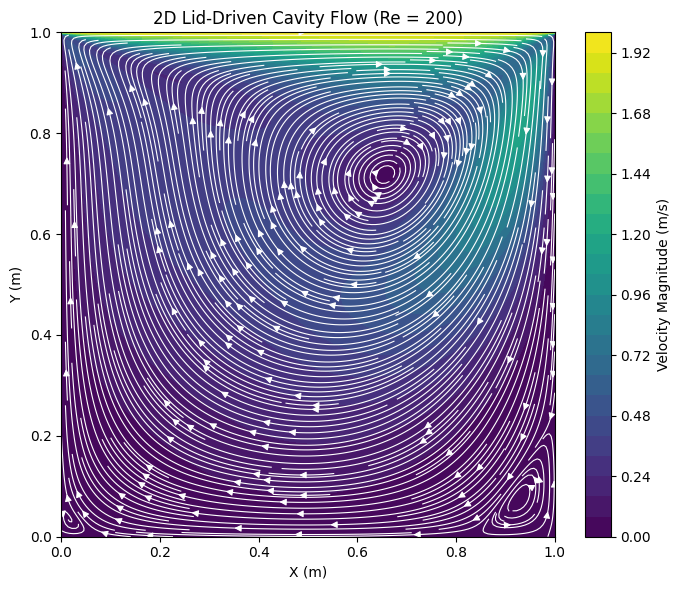

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# 1. PHYSICAL & NUMERICAL PARAMETERS
# =============================================================================
Lx, Ly = 1, 1  # Domain size (m)
nx, ny = 201, 201  # Grid resolution (nodes in x and y)
dx = Lx / (nx - 1)
dy = Ly / (ny - 1)

rho = 1.0  # Density (kg/m^3)
nu = 0.01  # Kinematic viscosity (m^2/s) 
dt = 1.0 / (2.0 * nu * (1.0 / dx**2 + 1.0 / dy**2))
nt = 4000  # Total time steps
u_lid = 2  # Moving top lid velocity (m/s)

# Mesh generation
x = np.linspace(0, Lx, nx)
y = np.linspace(0, Ly, ny)
X, Y = np.meshgrid(x, y)

# Field initialization
u = np.zeros((ny, nx))
v = np.zeros((ny, nx))
p = np.zeros((ny, nx))
b = np.zeros((ny, nx))

def check_stability(dx, dy, dt, nu, u_max=1.0, v_max=0.0):
    """Verifies CFL condition, viscous time-step limit, and Cell Reynolds numbers

    using existing simulation parameters.
    """
    # Stability calculations
    cfl = dt * (abs(u_max) / dx + abs(v_max) / dy)
    dt_viscous_max = 1.0 / (2.0 * nu * (1.0 / dx**2 + 1.0 / dy**2))
    re_dx = abs(u_max) * dx / nu
    re_dy = abs(v_max) * dy / nu
    re_cell_max = max(re_dx, re_dy)

    # Diagnostic Output
    print(f"{' NUMERICAL STABILITY CHECK ':=^50}")
    print(
        f"CFL Number        : {cfl:.4f}   (Target <= 0.5)  -> [{'PASS' if cfl <= 0.5 else 'WARN'}]"
    )
    print(
        f"Viscous dt Max    : {dt_viscous_max:.5f} s (Current: {dt:.5f} s) -> [{'PASS' if dt <= dt_viscous_max else 'FAIL'}]"
    )
    print(
        f"Cell Re (x / y)   : {re_dx:.2f} / {re_dy:.2f} (Target <= 2.0)  -> [{'PASS' if re_cell_max <= 2.0 else 'WARN'}]"
    )
    print("-" * 50)

    # Status summary
    if dt > dt_viscous_max or cfl > 1.0:
        print("STATUS: UNSTABLE — Solution will diverge (Floating-point NaN).")
    elif cfl > 0.5 or re_cell_max > 2.0:
        print(
            "STATUS: MARGINAL — Stable, but central differencing may show minor wiggles."
        )
    else:
        print("STATUS: STABLE — Safe to proceed with simulation.")
    print("=" * 50)


# Run check using existing parameters from your setup block
check_stability(dx, dy, dt, nu, u_max=u_lid)

# =============================================================================
# 2. PRESSURE POISSON SOLVER (JACOBI ITERATION)
# =============================================================================
def solve_pressure_poisson(p, b, dx, dy, nit=50):
    pn = np.empty_like(p)
    for _ in range(nit):
        pn[:] = p[:]
        p[1:-1, 1:-1] = (
            (pn[1:-1, 2:] + pn[1:-1, :-2]) * dy**2
            + (pn[2:, 1:-1] + pn[:-2, 1:-1]) * dx**2
            - b[1:-1, 1:-1] * (dx**2) * (dy**2)
        ) / (2 * (dx**2 + dy**2))

        # Boundary conditions: Neumann (dp/dn = 0) on all walls
        p[:, -1] = p[:, -2]  # Right wall
        p[:, 0] = p[:, 1]  # Left wall
        p[0, :] = p[1, :]  # Bottom wall
        p[-1, :] = p[-2, :]  # Top wall (lid)


    return p


# =============================================================================
# 3. MAIN TIME-STEPPING LOOP
# =============================================================================
for n in range(nt):
    un = u.copy()
    vn = v.copy()

    '''
    # Step A: Intermediate Velocity Field (Advection + Diffusion)
    u[1:-1, 1:-1] = un[1:-1, 1:-1] - dt * (
        un[1:-1, 1:-1] * (un[1:-1, 1:-1] - un[1:-1, :-2]) / dx
        + vn[1:-1, 1:-1] * (un[1:-1, 1:-1] - un[:-2, 1:-1]) / dy
    ) + nu * dt * (
        (un[1:-1, 2:] - 2 * un[1:-1, 1:-1] + un[1:-1, :-2]) / dx**2
        + (un[2:, 1:-1] - 2 * un[1:-1, 1:-1] + un[:-2, 1:-1]) / dy**2
    )

    v[1:-1, 1:-1] = vn[1:-1, 1:-1] - dt * (
        un[1:-1, 1:-1] * (vn[1:-1, 1:-1] - vn[1:-1, :-2]) / dx
        + vn[1:-1, 1:-1] * (vn[1:-1, 1:-1] - vn[:-2, 1:-1]) / dy
    ) + nu * dt * (
        (vn[1:-1, 2:] - 2 * vn[1:-1, 1:-1] + vn[1:-1, :-2]) / dx**2
        + (vn[2:, 1:-1] - 2 * vn[1:-1, 1:-1] + vn[:-2, 1:-1]) / dy**2
    )
    '''

    # Step A: Intermediate Velocity Field using 2nd-Order Central Differencing (CDS)
    u[1:-1, 1:-1] = (
        un[1:-1, 1:-1]
        - dt
        * (
            un[1:-1, 1:-1] * (un[1:-1, 2:] - un[1:-1, :-2]) / (2 * dx)
            + vn[1:-1, 1:-1] * (un[2:, 1:-1] - un[:-2, 1:-1]) / (2 * dy)
        )
        + nu
        * dt
        * (
            (un[1:-1, 2:] - 2 * un[1:-1, 1:-1] + un[1:-1, :-2]) / dx**2
            + (un[2:, 1:-1] - 2 * un[1:-1, 1:-1] + un[:-2, 1:-1]) / dy**2
        )
    )
    
    v[1:-1, 1:-1] = (
        vn[1:-1, 1:-1]
        - dt
        * (
            un[1:-1, 1:-1] * (vn[1:-1, 2:] - vn[1:-1, :-2]) / (2 * dx)
            + vn[1:-1, 1:-1] * (vn[2:, 1:-1] - vn[:-2, 1:-1]) / (2 * dy)
        )
        + nu
        * dt
        * (
            (vn[1:-1, 2:] - 2 * vn[1:-1, 1:-1] + vn[1:-1, :-2]) / dx**2
            + (vn[2:, 1:-1] - 2 * vn[1:-1, 1:-1] + vn[:-2, 1:-1]) / dy**2
        )
    )

    # Step B: Apply No-Slip and Lid Velocity Boundary Conditions
    u[0, :] = 0.0  # Bottom
    u[:, 0] = 0.0  # Left
    u[:, -1] = 0.0  # Right
    u[-1, :] = u_lid  # Top Lid (Moving)

    v[0, :] = 0.0  # Bottom
    v[:, 0] = 0.0  # Left
    v[:, -1] = 0.0  # Right
    v[-1, :] = 0.0  # Top Lid

    # Step C: Source term for Pressure Poisson Equation (Divergence of u*)
    b[1:-1, 1:-1] = (rho / dt) * (
        (u[1:-1, 2:] - u[1:-1, :-2]) / (2 * dx)
        + (v[2:, 1:-1] - v[:-2, 1:-1]) / (2 * dy)
    )

    # Step D: Solve Pressure Poisson Equation
    p = solve_pressure_poisson(p, b, dx, dy, nit=50)

    # Step E: Velocity Correction (Project onto divergence-free space)
    u[1:-1, 1:-1] -= (dt / rho) * (p[1:-1, 2:] - p[1:-1, :-2]) / (2 * dx)
    v[1:-1, 1:-1] -= (dt / rho) * (p[2:, 1:-1] - p[:-2, 1:-1]) / (2 * dy)

    # Re-enforce Velocity Boundary Conditions
    u[0, :] = 0.0
    u[:, 0] = 0.0
    u[:, -1] = 0.0
    u[-1, :] = u_lid

    v[0, :] = 0.0
    v[:, 0] = 0.0
    v[:, -1] = 0.0
    v[-1, :] = 0.0

# =============================================================================
# 4. VISUALIZATION
# =============================================================================
vel_mag = np.sqrt(u**2 + v**2)

plt.figure(figsize=(7, 6), dpi=100)
plt.contourf(X, Y, vel_mag, levels=30, cmap="viridis")
plt.colorbar(label="Velocity Magnitude (m/s)")
plt.streamplot(X, Y, u, v, color="white", linewidth=0.8, density=4)
plt.title(
    f"2D Lid-Driven Cavity Flow (Re = {int(u_lid * Lx / nu)})", fontsize=12
)
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.xlim(0, Lx)
plt.ylim(0, Ly)
plt.tight_layout()
plt.show()

=========== NUMERICAL STABILITY CHECK ============
CFL Number        : 0.2500   (Target <= 0.5)  -> [PASS]
Viscous dt Max    : 0.00063 s (Current: 0.00063 s) -> [PASS]
Cell Re (x / y)   : 1.00 / 0.00 (Target <= 2.0)  -> [PASS]
--------------------------------------------------
STATUS: STABLE — Safe to proceed with simulation.


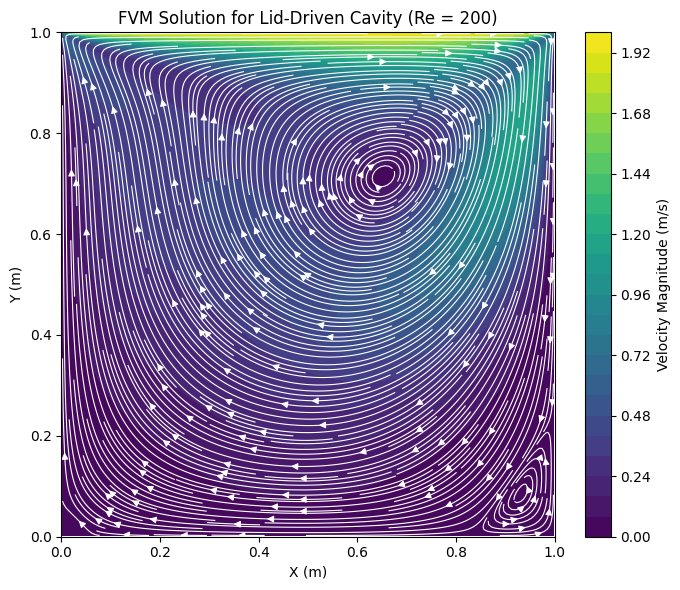

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# 1. PHYSICAL & GRID SETUP (Cell-Centered FVM with Ghost Cells)
# =============================================================================
Lx, Ly = 1.0, 1.0
nx, ny = 200, 200  # Number of interior Control Volumes (cells)
dx = Lx / nx
dy = Ly / ny

rho = 1.0
nu = 0.01  # Re = 100 (with u_lid = 1.0)
u_lid = 2.0

# dt = 0.0015
dt = 1.0 / (2.0 * nu * (1.0 / dx**2 + 1.0 / dy**2))
nt = 4000  # Total physical time = 6.0 seconds

# Arrays include 1 layer of surrounding ghost cells (size: ny+2, nx+2)
u = np.zeros((ny + 2, nx + 2))
v = np.zeros((ny + 2, nx + 2))
p = np.zeros((ny + 2, nx + 2))

def check_stability(dx, dy, dt, nu, u_max=1.0, v_max=0.0):
    """Verifies CFL condition, viscous time-step limit, and Cell Reynolds numbers

    using existing simulation parameters.
    """
    # Stability calculations
    cfl = dt * (abs(u_max) / dx + abs(v_max) / dy)
    dt_viscous_max = 1.0 / (2.0 * nu * (1.0 / dx**2 + 1.0 / dy**2))
    re_dx = abs(u_max) * dx / nu
    re_dy = abs(v_max) * dy / nu
    re_cell_max = max(re_dx, re_dy)

    # Diagnostic Output
    print(f"{' NUMERICAL STABILITY CHECK ':=^50}")
    print(
        f"CFL Number        : {cfl:.4f}   (Target <= 0.5)  -> [{'PASS' if cfl <= 0.5 else 'WARN'}]"
    )
    print(
        f"Viscous dt Max    : {dt_viscous_max:.5f} s (Current: {dt:.5f} s) -> [{'PASS' if dt <= dt_viscous_max else 'FAIL'}]"
    )
    print(
        f"Cell Re (x / y)   : {re_dx:.2f} / {re_dy:.2f} (Target <= 2.0)  -> [{'PASS' if re_cell_max <= 2.0 else 'WARN'}]"
    )
    print("-" * 50)

    # Status summary
    if dt > dt_viscous_max or cfl > 1.0:
        print("STATUS: UNSTABLE — Solution will diverge (Floating-point NaN).")
    elif cfl > 0.5 or re_cell_max > 2.0:
        print(
            "STATUS: MARGINAL — Stable, but central differencing may show minor wiggles."
        )
    else:
        print("STATUS: STABLE — Safe to proceed with simulation.")
    print("=" * 50)

# Run check using existing parameters from your setup block
check_stability(dx, dy, dt, nu, u_max=u_lid)

def apply_ghost_boundary_conditions(u, v):
    """Sets ghost cell values to enforce exact face boundary conditions."""
    # Bottom Wall (y = 0): No-slip (u_face = 0, v_face = 0)
    u[0, :] = -u[1, :]
    v[0, :] = -v[1, :]

    # Top Wall (y = Ly): Moving Lid (u_face = u_lid, v_face = 0)
    u[-1, :] = 2.0 * u_lid - u[-2, :]
    v[-1, :] = -v[-2, :]

    # Left Wall (x = 0): No-slip (u_face = 0, v_face = 0)
    u[:, 0] = -u[:, 1]
    v[:, 0] = -v[:, 1]

    # Right Wall (x = Lx): No-slip (u_face = 0, v_face = 0)
    u[:, -1] = -u[:, -2]
    v[:, -1] = -v[:, -2]


def solve_pressure_poisson_fvm(p, b, dx, dy, nit=40):
    """Solves integrated Pressure Poisson Equation over Control Volumes."""
    for _ in range(nit):
        p[1:-1, 1:-1] = (
            (p[1:-1, 2:] + p[1:-1, :-2]) * dy**2
            + (p[2:, 1:-1] + p[:-2, 1:-1]) * dx**2
            - b * (dx**2) * (dy**2)
        ) / (2.0 * (dx**2 + dy**2))

        # Zero Neumann Pressure BC (dp/dn = 0) at physical faces
        p[:, 0] = p[:, 1]
        p[:, -1] = p[:, -2]
        p[0, :] = p[1, :]
        p[-1, :] = p[-2, :]
    return p


# =============================================================================
# 2. MAIN TIME-STEPPING LOOP
# =============================================================================
apply_ghost_boundary_conditions(u, v)

for n in range(nt):
    # --- Step A: Interpolate Cell-Center Velocities to Cell Faces (CDS) ---
    u_e = 0.5 * (u[1:-1, 1:-1] + u[1:-1, 2:])
    u_w = 0.5 * (u[1:-1, 1:-1] + u[1:-1, :-2])
    v_e = 0.5 * (v[1:-1, 1:-1] + v[1:-1, 2:])
    v_w = 0.5 * (v[1:-1, 1:-1] + v[1:-1, :-2])

    u_n = 0.5 * (u[1:-1, 1:-1] + u[2:, 1:-1])
    u_s = 0.5 * (u[1:-1, 1:-1] + u[:-2, 1:-1])
    v_n = 0.5 * (v[1:-1, 1:-1] + v[2:, 1:-1])
    v_s = 0.5 * (v[1:-1, 1:-1] + v[:-2, 1:-1])

    # --- Step B: Integrated Net Convective & Diffusive Surface Fluxes ---
    # u-momentum balance per unit volume
    conv_u = (u_e * u_e - u_w * u_w) / dx + (v_n * u_n - v_s * u_s) / dy
    diff_u = nu * (
        (u[1:-1, 2:] - 2 * u[1:-1, 1:-1] + u[1:-1, :-2]) / dx**2
        + (u[2:, 1:-1] - 2 * u[1:-1, 1:-1] + u[:-2, 1:-1]) / dy**2
    )

    # v-momentum balance per unit volume
    conv_v = (u_e * v_e - u_w * v_w) / dx + (v_n * v_n - v_s * v_s) / dy
    diff_v = nu * (
        (v[1:-1, 2:] - 2 * v[1:-1, 1:-1] + v[1:-1, :-2]) / dx**2
        + (v[2:, 1:-1] - 2 * v[1:-1, 1:-1] + v[:-2, 1:-1]) / dy**2
    )

    # Predictor step: Tentative velocity field u*
    u[1:-1, 1:-1] += dt * (-conv_u + diff_u)
    v[1:-1, 1:-1] += dt * (-conv_v + diff_v)
    apply_ghost_boundary_conditions(u, v)

    # --- Step C: Calculate Net Mass Flux Divergence over Control Volume ---
    u_e_star = 0.5 * (u[1:-1, 1:-1] + u[1:-1, 2:])
    u_w_star = 0.5 * (u[1:-1, 1:-1] + u[1:-1, :-2])
    v_n_star = 0.5 * (v[1:-1, 1:-1] + v[2:, 1:-1])
    v_s_star = 0.5 * (v[1:-1, 1:-1] + v[:-2, 1:-1])

    b = (rho / dt) * ((u_e_star - u_w_star) / dx + (v_n_star - v_s_star) / dy)

    # --- Step D: Pressure Poisson Solution ---
    p = solve_pressure_poisson_fvm(p, b, dx, dy, nit=40)

    # --- Step E: Corrector Step (Project onto Mass-Conserved Field) ---
    u[1:-1, 1:-1] -= (dt / rho) * (p[1:-1, 2:] - p[1:-1, :-2]) / (2.0 * dx)
    v[1:-1, 1:-1] -= (dt / rho) * (p[2:, 1:-1] - p[:-2, 1:-1]) / (2.0 * dy)
    apply_ghost_boundary_conditions(u, v)

# =============================================================================
# 3. VISUALIZATION
# =============================================================================
# Extract interior cell-center coordinates
x_centers = np.linspace(dx / 2, Lx - dx / 2, nx)
y_centers = np.linspace(dy / 2, Ly - dy / 2, ny)
X, Y = np.meshgrid(x_centers, y_centers)

u_int = u[1:-1, 1:-1]
v_int = v[1:-1, 1:-1]
vel_mag = np.sqrt(u_int**2 + v_int**2)

plt.figure(figsize=(7, 6), dpi=100)
plt.contourf(X, Y, vel_mag, levels=30, cmap="viridis")
plt.colorbar(label="Velocity Magnitude (m/s)")
plt.streamplot(X, Y, u_int, v_int, color="white", linewidth=0.8, density=4)
plt.title(f"FVM Solution for Lid-Driven Cavity (Re = {int(u_lid*Lx/nu)})")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.xlim(0, Lx)
plt.ylim(0, Ly)
plt.tight_layout()
plt.show()